In [47]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
plt.style.use('ggplot')
np.random.seed(72)

### Создание выборки

In [48]:
def sample_generation(N):
    Psi = np.zeros((N, 6))
    Psi[:, 0] = 1
    Psi[:, 1:6] = np.random.uniform(low = -1, high=1, size=(N, 5))
    a = 2+3*Psi[:,1]-2*Psi[:,2]+Psi[:,3]+Psi[:,4]-Psi[:,5]
    Y = np.random.normal(loc=a, scale=1.5, size=N)
    return Psi, Y
Psi, Y = sample_generation(50)

### Пункт а. Проверка мультиколлинеарности

In [49]:
def TSS(sample):
    mean_val = np.mean(sample)
    return np.sum((sample - mean_val)**2)

In [50]:
def check_multicollinearity(sample):
    for i in range(5):
        Y_i = sample[:, i + 1]
        Psi_i = np.delete(sample[:, 0:6], i + 1, axis = 1)
        F_inv_i = np.linalg.inv(Psi_i.T @ Psi_i)
        beta_i = F_inv_i @ Psi_i.T @ Y_i
        e = Y_i - Psi_i @ beta_i
        rss = e @ e
        tss = TSS(Y_i)
        R_2 = (tss - rss)/tss
        print(f"Переменная {i+1}, R^2 = {R_2}")
check_multicollinearity(Psi)

Переменная 1, R^2 = 0.04399599685361518
Переменная 2, R^2 = 0.037730769168289345
Переменная 3, R^2 = 0.18612747441013192
Переменная 4, R^2 = 0.0957282563809614
Переменная 5, R^2 = 0.12722427826502727


### Пункт б. Коэффициенты регрессии

In [51]:
def regression(psi, y):
    F_inv = np.linalg.inv(psi.T @ psi)
    beta = F_inv @ psi.T @ y
    return beta
regression_coefficients = regression(Psi, Y)
print(regression_coefficients)

[ 1.85366629  2.93747516 -2.19772724  0.9367336   1.22917621 -0.67764286]


### Проверка значимости

In [52]:
def check_coefficients_significance(Psi, Y, regression_coefficients):
    e = Y - Psi @ regression_coefficients
    rss = e @ e
    for i in range(len(regression_coefficients)):
        F_inv = np.linalg.inv(Psi.T @ Psi)
        n, p = Psi.shape
        beta_i = regression_coefficients[i]
        delta_ = (beta_i * np.sqrt(n-p))/np.sqrt(rss*F_inv[i,i])
        p_value_i = 2 * (1-stats.t(n-p).cdf(abs(delta_)))
        print(f"Коэффициент {i}, p-value: {p_value_i}")

check_coefficients_significance(Psi, Y, regression_coefficients)

Коэффициент 0, p-value: 4.462608060862294e-11
Коэффициент 1, p-value: 4.089373284443809e-11
Коэффициент 2, p-value: 3.474288345906018e-08
Коэффициент 3, p-value: 0.014181365951051239
Коэффициент 4, p-value: 0.0006295927180954841
Коэффициент 5, p-value: 0.07630977286515184


### Коэффициент детерминации и значимость всей регрессии

In [53]:
def R_2(Psi, Y, regression_coefficients):
    e = Y - Psi @ regression_coefficients
    rss = e @ e
    tss = TSS(Y)
    r_2 = (tss-rss)/tss
    return r_2
print(R_2(Psi, Y, regression_coefficients))

0.7871451888207863


In [54]:
def regression_significance(Psi, Y, regression_coefficients):
    n, p = Psi.shape
    r_2 = R_2(Psi, Y, regression_coefficients)
    delta_ = (r_2*(n-p))/((1-r_2)*(p-1))
    p_value = 1 - stats.f(p-1, n-p).cdf(delta_)
    print(f"p_value = {p_value}")
regression_significance(Psi, Y, regression_coefficients)

p_value = 9.903189379656396e-14


### Пункт d. Значение в xk = 0 и 95% доверительный интервал

In [55]:
gamma = 0.95
def confidence_interval(Psi, Y, regression_coefficients):
    n, p = Psi.shape
    F_inv = np.linalg.inv(Psi.T @ Psi)
    e = Y - Psi @ regression_coefficients
    rss = e @ e

    Psi_0 = np.array([1,0,0,0,0,0])
    y0 = regression_coefficients[0]
    print(y0)
    delta = np.sqrt(rss*(1+Psi_0 @ F_inv @ Psi_0.T)/(n-p))
    left_border = y0-delta * stats.t(n-p).ppf((1+gamma)/2)
    right_border = y0-delta * stats.t(n-p).ppf((1-gamma)/2)
    print(f"{left_border} < eta0 < {right_border}")
confidence_interval(Psi, Y, regression_coefficients)

1.8536662888826605
-0.8486663312152882 < eta0 < 4.555998908980609


### Пункт е. Проверка предположения о независимости ошибок измерения

In [56]:
def number_of_inversions(sample: np.ndarray):
    inversions = 0
    for i in range(sample.size):
        element = sample[i]
        inversions += np.sum(sample[i:] < element)
    return inversions

In [57]:
def independence_of_errors(Psi, Y, regression_coefficients):
    n, _ = Psi.shape
    e = Y - Psi @ regression_coefficients
    I = number_of_inversions(e)
    print(I)
    delta_ = (I - n*(n-1)/4)/np.sqrt((n**3)/36)
    p_value = 2 * stats.norm.sf(abs(delta_))
    print(f"p-value: {p_value}")
independence_of_errors(Psi, Y, regression_coefficients)

602
p-value: 0.8585730491483827


### Пункт f. Проверка предположения о нормальной распределённости ошибок

In [58]:
N = 50000

def F(x, sigma, mu = 0):
    return stats.norm.cdf(x, loc = mu, scale = sigma)

def emp_f_norm(n):
    return np.arange(n + 1) / n

def sample_delta(sample, F_emp, n):
    deltas_emp_f_ = np.zeros(n)
    boot_sigma = np.std(sample, ddof=1)
    for j in range(n):
        deltas_emp_f_[j] = max(
            abs(F(sample[j], boot_sigma,) - F_emp[j]),
            abs(F_emp[j+1] - F(sample[j], boot_sigma))
        )
    return np.sqrt(n)*max(deltas_emp_f_)

def parametric_bootstrap(e, n, F_emp, N):
    sigma_est = np.std(e, ddof=1)
    boot_deltas = np.zeros(N)
    for i in range(N):
        bootstrap_sample = np.sort(np.random.normal(loc = 0, scale = sigma_est, size = n))
        boot_deltas[i] = sample_delta(bootstrap_sample, F_emp, n)
    return boot_deltas

def checking_normal_distribution_errors(Psi, Y, regression_coefficients, N):
    n, _ = Psi.shape
    e = Y - Psi @ regression_coefficients
    F_emp = emp_f_norm(n)
    delta_ = sample_delta(np.sort(e), F_emp, n)
    bootstrap_deltas = parametric_bootstrap(e, n, F_emp, N)
    p_value = np.sum(bootstrap_deltas > delta_) / N
    print(f"p-value: {p_value}")
checking_normal_distribution_errors(Psi, Y, regression_coefficients, N)

p-value: 0.22816


### Пункт f. Исследование регрессии на выбросы

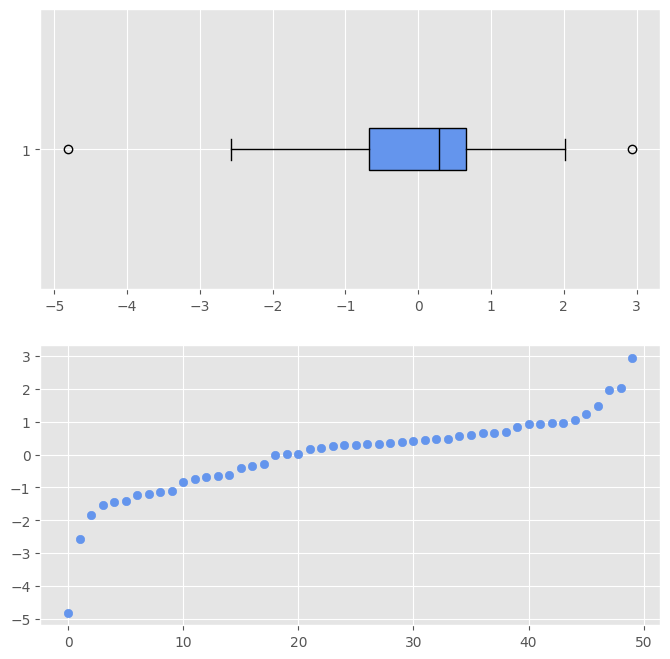

In [59]:
def outliers_in_regression(Psi, Y, regression_coefficients):
    e = Y - Psi @ regression_coefficients
    sort_idx = np.argsort(e)
    e_sort = e[sort_idx]
    i = np.arange(e_sort.size)

    figure, axes = plt.subplots(2, 1, figsize=(8, 8))
    bp = axes[0].boxplot(e_sort, vert=False, patch_artist=True)
    bp['boxes'][0].set_facecolor('cornflowerblue')
    bp['medians'][0].set_color('black')

    axes[1].scatter(i, e_sort, color = "cornflowerblue")

    plt.show()
    return sort_idx[0], sort_idx[1], sort_idx[-1]
outliers_idx = outliers_in_regression(Psi, Y, regression_coefficients)

#### Видим: по-хорошему выкинуть первые 2 и последнюю точки и проверить R^2

In [60]:
def print_old_new_R_2(Psi, Y, regression_coefficients, outliers_idx):
    print(f"R^2 до: {R_2(Psi, Y, regression_coefficients)}")
    mask = np.ones(len(Y), dtype=bool)
    mask[np.asarray(outliers_idx).flatten()] = False
    Psi_clean = Psi[mask]
    Y_clean   = Y[mask]
    regression_coefficients_new = regression(Psi_clean, Y_clean)
    print(f"R^2 после: {R_2(Psi_clean, Y_clean, regression_coefficients_new)}")
print_old_new_R_2(Psi, Y, regression_coefficients, outliers_idx)

R^2 до: 0.7871451888207863
R^2 после: 0.8694125834842912


### Пункт h. Кросс-проверка регрессии

In [61]:
def cross_validation(Psi, Y):
    n, _ = Psi.shape
    cvss = 0
    for i in range(n):
        Psi_wtout_i = np.delete(Psi, i, axis = 0)
        Y_wtout_i = np.delete(Y, i, axis = 0)
        regression_coefficients_i = regression(Psi_wtout_i, Y_wtout_i)
        cvss += ((Psi[i] @ regression_coefficients_i) - Y[i])**2
    tss = TSS(Y)
    R_cv = (tss - cvss)/tss
    print(R_cv)
cross_validation(Psi, Y)

0.7243304032422618


### Пункт i. Проверка адекватности регрессии

#### Кластер из 5 близких точек

In [62]:
claster_idx = [1, 2, 14, 17, 23]
print(Psi[claster_idx])

[[ 1.          0.17569495  0.43214758 -0.65333192 -0.86651541  0.00135775]
 [ 1.         -0.13570561  0.89335184 -0.16748026 -0.50506063 -0.19171632]
 [ 1.          0.39472634  0.41417265 -0.40712473 -0.3508474  -0.4506422 ]
 [ 1.         -0.01039646  0.47790823 -0.71881386 -0.75147405 -0.63407896]
 [ 1.          0.38706297  0.69772502 -0.56119609 -0.3851366   0.16710069]]


In [63]:
def adequacy_of_model(Psi, Y, claster_idx):
    Y_claster = Y[claster_idx]
    sigma_2 = np.var(Y_claster, ddof = 1)
    Psi_without_claster = np.delete(Psi, claster_idx, axis = 0)
    Y_without_claster = np.delete(Y, claster_idx, axis = 0)
    n, p = Psi.shape
    m = len(claster_idx)
    n_ = n - m
    F_inv = np.linalg.inv(Psi_without_claster.T @ Psi_without_claster)
    beta = F_inv @ Psi_without_claster.T @ Y_without_claster
    e = Y_without_claster - Psi_without_claster @ beta
    rss = e @ e
    delta = rss/((n_ - p)*sigma_2)
    p_value = stats.f.sf(delta, n_-p, m-1)
    print(f"p-value: {p_value}")
adequacy_of_model(Psi, Y, claster_idx)

p-value: 0.893434115498833


### Пункт j

#### Удаляем 5ю наименее значимую переменную

In [64]:
def new_psi_y(Psi, Y):
    n, _ = Psi.shape
    Psi_new = np.delete(Psi, 5, axis = 1)
    a = 2+3*Psi[:,1]-2*Psi[:,2]+Psi[:,3]+Psi[:,4]
    Y_new = Y
    return Psi_new, Y_new
Psi_new, Y_new = new_psi_y(Psi, Y)

#### повторяем пункт б

In [65]:
new_regression_coefficients = regression(Psi_new, Y_new)
print(new_regression_coefficients)

[ 1.70604792  3.04635161 -2.18540183  0.7692896   1.18070815]


In [66]:
check_coefficients_significance(Psi_new, Y_new, new_regression_coefficients)

Коэффициент 0, p-value: 8.540790297217882e-11
Коэффициент 1, p-value: 1.5289547405927806e-11
Коэффициент 2, p-value: 6.20155862218752e-08
Коэффициент 3, p-value: 0.040083794524983674
Коэффициент 4, p-value: 0.0011906972449491349


#### Повторяем пункт с

In [67]:
print(f"R^2 = {R_2(Psi_new, Y_new, new_regression_coefficients)}")

R^2 = 0.77120515920677


In [68]:
regression_significance(Psi_new, Y_new, new_regression_coefficients)

p_value = 7.105427357601002e-14


#### Сравнение вложенных регрессий

In [69]:
def  comparison_of_regressions(
    Psi, Y, regression_coefficients,
    Psi_new, Y_new, new_regression_coefficients
    ):
    n, p = Psi.shape
    n_new, p_new = Psi_new.shape
    e = Y - Psi @ regression_coefficients
    rss = e @ e
    e_new = Y_new - Psi_new @ new_regression_coefficients
    rss_new = e_new @ e_new
    delta = ((rss_new - rss)/(p - p_new))/(rss/(n-p))
    p_value = stats.f.sf(delta, p-p_new, n-p)
    print(f"p-value = {p_value}")

comparison_of_regressions(
    Psi, Y, regression_coefficients,
    Psi_new, Y_new, new_regression_coefficients)

p-value = 0.07630977286515224


### Пункт k. Сравнение уравнений регрессии бутстрапом

In [70]:
def Rss(Psi, Y):
    beta = regression(Psi, Y)
    e = Y - Psi @ beta
    return e @ e

In [ ]:
N_ = 1000
def bootstrap_comparison(Psi, Y, Psi_new, Y_new, N):
    n, _ = Psi.shape
    rss = Rss(Psi, Y)
    rss_new = Rss(Psi_new, Y_new)
    h = rss_new - rss

    deltas_h_list = np.zeros(N)

    for i in range(N):
        indices = np.random.choice(n, size=n, replace=True)
        Psi_boot = Psi[indices]
        Y_boot   = Y[indices]
        Psi_new_boot = Psi_new[indices]
        Y_new_boot = Y_new[indices]
        rss_boot = Rss(Psi_boot, Y_boot)
        rss_new_boot = Rss(Psi_new_boot, Y_new_boot)
        h_boot = rss_new_boot - rss_boot
        deltas_h_list[i] = h_boot - h
    
    deltas_h_list = np.sort(deltas_h_list)
    left_board = h - deltas_h_list[-1]
    right_board = h - deltas_h_list[int(0.05 * N)]
    print(f"{left_board} < h < {right_board}")

bootstrap_comparison(Psi, Y, Psi_new, Y_new, N_)

-19.946881577387373 < h < 11.041580031663166
